In [1]:
import sys, os, time
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from IPython.display import display, HTML

project_root = Path.cwd().parents[1]
sys.path.insert(0, str(project_root / 'common' / 'scripts'))
from generate_charts import setup_plot_style, TULEVA_BLUE, TULEVA_NAVY, TULEVA_MID_BLUE

setup_plot_style()

COMPETITOR_COLORS = {
    'Tuleva': TULEVA_BLUE,
    'Swedbank': '#FF8C00',
    'LHV': '#8B4513',
    'SEB': '#51c26c',
    'Luminor': '#7B2D8E',
}

css_path = project_root / 'common' / 'branding' / 'style.css'
display(HTML(f'<link rel="stylesheet" href="{css_path}">'))

print("Setup complete")

Setup complete


In [2]:
FUNDS = {
    # Tuleva
    'EE3600109435': {'name': 'Tuleva Maailma Aktsiate Pensionifond', 'short': 'Tuleva Aktsiad', 'manager': 'Tuleva', 'category': 'index'},
    'EE3600109443': {'name': 'Tuleva Maailma Võlakirjade Pensionifond', 'short': 'Tuleva Võlakirjad', 'manager': 'Tuleva', 'category': 'bond'},
    # LHV
    'EE3600019832': {'name': 'LHV Pensionifond Ettevõtlik',  'short': 'LHV Ettevõtlik',  'manager': 'LHV', 'category': 'active'},
    'EE3600109401': {'name': 'LHV Pensionifond Indeks',      'short': 'LHV Indeks',      'manager': 'LHV', 'category': 'index'},
    'EE3600019766': {'name': 'LHV Pensionifond Julge',       'short': 'LHV Julge',       'manager': 'LHV', 'category': 'active'},
    'EE3600019782': {'name': 'LHV Pensionifond Rahulik',     'short': 'LHV Rahulik',     'manager': 'LHV', 'category': 'conservative'},
    'EE3600019774': {'name': 'LHV Pensionifond Tasakaalukas', 'short': 'LHV Tasakaalukas', 'manager': 'LHV', 'category': 'active'},
    'EE3600109476': {'name': 'LHV Pensionifond Eesti',       'short': 'LHV Eesti',       'manager': 'LHV', 'category': 'active'},
    'EE3600019824': {'name': 'LHV Pensionifond S',           'short': 'LHV S',           'manager': 'LHV', 'category': 'active'},
    'EE3600001723': {'name': 'LHV Pensionifond Roheline',    'short': 'LHV Roheline',    'manager': 'LHV', 'category': 'active'},
    # SEB
    'EE3600001699': {'name': 'SEB pensionifond 18+',    'short': 'SEB 18+',    'manager': 'SEB', 'category': 'active'},
    'EE3600019725': {'name': 'SEB pensionifond 55+',    'short': 'SEB 55+',    'manager': 'SEB', 'category': 'active'},
    'EE3600098612': {'name': 'SEB pensionifond 60+',    'short': 'SEB 60+',    'manager': 'SEB', 'category': 'mixed'},
    'EE3600019717': {'name': 'SEB pensionifond 65+',    'short': 'SEB 65+',    'manager': 'SEB', 'category': 'conservative'},
    'EE3600109427': {'name': 'SEB pensionifond indeks', 'short': 'SEB Indeks', 'manager': 'SEB', 'category': 'index'},
    'EE3600103297': {'name': 'SEB Energiline Pensionifond', 'short': 'SEB Energiline', 'manager': 'SEB', 'category': 'active'},
    # Swedbank
    'EE3600001814': {'name': 'Swedbank Pensionifond Indeks',                      'short': 'Swedbank Indeks',  'manager': 'Swedbank', 'category': 'index'},
    'EE3600019741': {'name': 'Swedbanki pensionifond 1960-69 sündinutele',        'short': 'Swedbank K1960',   'manager': 'Swedbank', 'category': 'mixed'},
    'EE3600019758': {'name': 'Swedbanki pensionifond 1970-79 sündinutele',        'short': 'Swedbank K1970',   'manager': 'Swedbank', 'category': 'mixed'},
    'EE3600103248': {'name': 'Swedbanki pensionifond 1980-89 sündinutele',        'short': 'Swedbank K1980',   'manager': 'Swedbank', 'category': 'mixed'},
    'EE3600001848': {'name': 'Swedbanki pensionifond 2000-09 sündinutele',        'short': 'Swedbank 2000-09', 'manager': 'Swedbank', 'category': 'mixed'},
    'EE3600109393': {'name': 'Swedbanki pensionifond indeks 1990-99 sündinutele', 'short': 'Swedbank K1990',   'manager': 'Swedbank', 'category': 'index'},
    'EE3600019733': {'name': 'Swedbanki pensionifond Konservatiivne',             'short': 'Swedbank Kons.',   'manager': 'Swedbank', 'category': 'conservative'},
    # Luminor
    'EE3600103503': {'name': 'Luminor 16-50 pensionifond',  'short': 'Luminor 16-50',  'manager': 'Luminor', 'category': 'mixed'},
    'EE3600098430': {'name': 'Luminor 50-56 pensionifond',  'short': 'Luminor 50-56',  'manager': 'Luminor', 'category': 'mixed'},
    'EE3600098448': {'name': 'Luminor 56+ pensionifond',    'short': 'Luminor 56+',    'manager': 'Luminor', 'category': 'mixed'},
    'EE3600098455': {'name': 'Luminor 61-65 pensionifond',  'short': 'Luminor 61-65',  'manager': 'Luminor', 'category': 'conservative'},
    'EE3600001806': {'name': 'Luminor Indeks Pensionifond', 'short': 'Luminor Indeks', 'manager': 'Luminor', 'category': 'index'},
}

print(f"Defined {len(FUNDS)} funds")

Defined 28 funds


In [3]:
CACHE_FILE = Path('data/ii_pillar_switching.csv')
API_BASE = 'https://www.pensionikeskus.ee/ws/et/stats/fund-pev'

# Period dates from 2020 onwards (3 per year: Jan, May, Sep)
PERIOD_DATES = [
    '2020-01-02', '2020-05-04', '2020-09-01',
    '2021-01-04', '2021-05-03', '2021-09-01',
    '2022-01-03', '2022-05-02', '2022-09-01',
    '2023-01-02', '2023-05-02', '2023-09-01',
    '2024-01-02', '2024-05-02', '2024-09-02',
    '2025-01-02', '2025-05-02', '2025-09-01',
    '2026-01-02',
]

MONTH_TO_Q = {1: 'Q1', 5: 'Q2', 9: 'Q3'}

if CACHE_FILE.exists():
    df = pd.read_csv(CACHE_FILE)
    print(f"Loaded {len(df)} rows from cache")
else:
    rows = []
    for i, date_str in enumerate(PERIOD_DATES):
        if i > 0:
            time.sleep(0.3)
        resp = requests.get(f'{API_BASE}/{date_str}')
        resp.raise_for_status()
        data = resp.json()
        
        for isin, stats in data['stats'].items():
            if stats['type'] != 'F':
                continue
            rows.append({
                'period_date': date_str,
                'isin': isin,
                'inflow_count': stats['count_from_fund'],
                'outflow_count': stats['count_to_fund'],
                'inflow_amount': stats['amount_from_fund'],
                'outflow_amount': stats['amount_to_fund'],
            })
        
        print(f"  {date_str}: {len(data['stats'])} funds")
    
    df = pd.DataFrame(rows)
    CACHE_FILE.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(CACHE_FILE, index=False)
    print(f"Saved {len(df)} rows to {CACHE_FILE}")

# Enrich with fund metadata
fund_meta = pd.DataFrame.from_dict(FUNDS, orient='index').reset_index().rename(columns={'index': 'isin'})
df = df.merge(fund_meta, on='isin', how='left')

unknown = df[df['manager'].isna()]['isin'].unique()
if len(unknown):
    print(f"WARNING: Unknown ISINs: {unknown}")
    df = df[df['manager'].notna()]

# Create period labels
df['period_month'] = pd.to_datetime(df['period_date']).dt.month
df['period_year'] = pd.to_datetime(df['period_date']).dt.year
df['period_label'] = df.apply(lambda r: f"{r['period_year']} {MONTH_TO_Q[r['period_month']]}", axis=1)

# Ordered period labels for consistent x-axis
PERIOD_LABELS = df.sort_values('period_date')['period_label'].unique().tolist()

print(f"\nDataset: {len(df)} rows, {df['isin'].nunique()} funds, {len(PERIOD_LABELS)} periods")
print(f"Periods: {PERIOD_LABELS[0]} to {PERIOD_LABELS[-1]}")

Loaded 486 rows from cache

Dataset: 486 rows, 28 funds, 19 periods
Periods: 2020 Q1 to 2026 Q1


# II samba fondivalikute (vahetuste) turg

Andmed: [Pensionikeskus](https://www.pensionikeskus.ee/statistika/ii-sammas/kogumispensioni-fondide-pik-vahetus/), 2020 Q1 – 2026 Q1 (19 vahetusperioodi).

Iga aasta toimub 3 vahetusperioodi: jaanuar (Q1), mai (Q2), september (Q3).

## Sissevool fondide kaupa

Mitu inimest vahetas oma fondi valitud fondi kasuks igal vahetusperioodil?

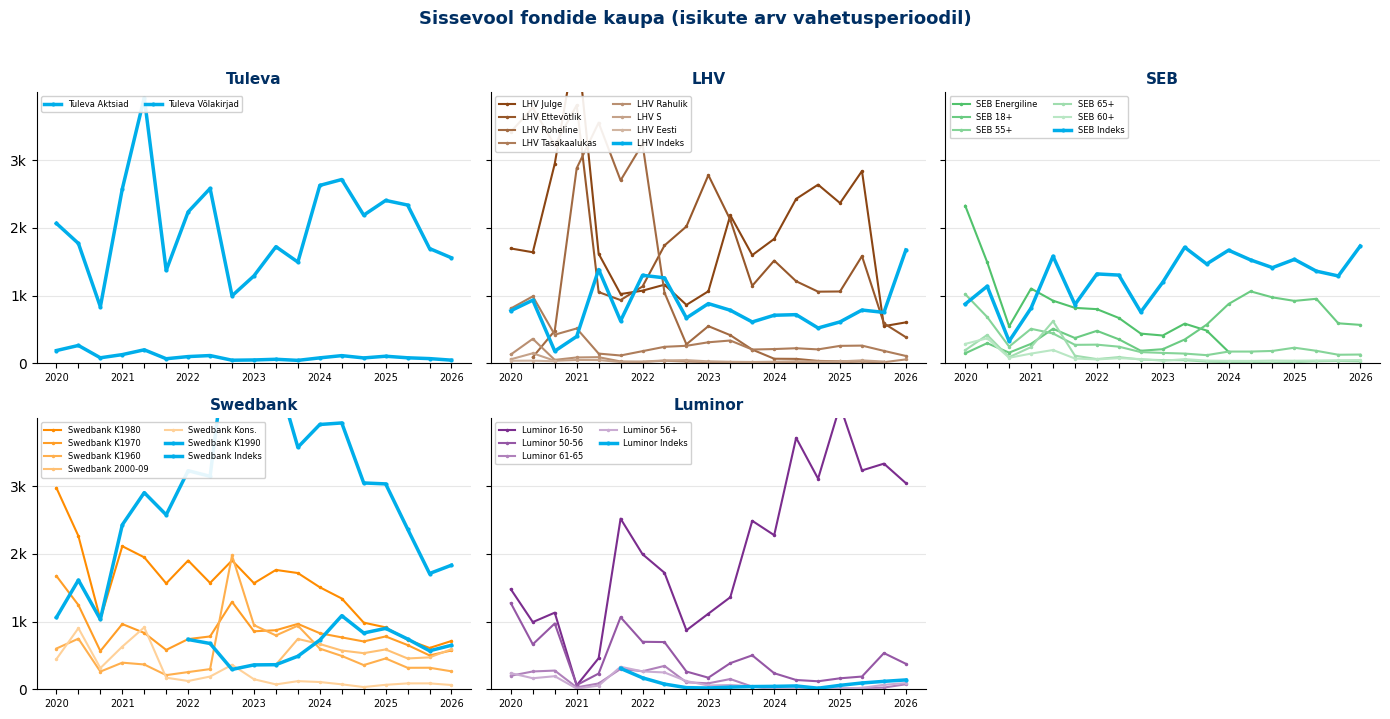

In [4]:
MANAGER_ORDER = ['Tuleva', 'LHV', 'SEB', 'Swedbank', 'Luminor']
INDEX_HIGHLIGHT = TULEVA_BLUE

import matplotlib.colors as mcolors

def get_fund_colors(manager, n):
    base = COMPETITOR_COLORS[manager]
    rgb = mcolors.to_rgb(base)
    colors = []
    for i in range(n):
        factor = 0.4 + 0.6 * (i / max(n - 1, 1))
        colors.append(tuple(1 - factor * (1 - c) for c in rgb))
    return colors[::-1]

# Build x-axis labels: show year at Q1, empty otherwise; tick at every period
PERIOD_XLABELS = []
for label in PERIOD_LABELS:
    year, q = label.split(' ')
    PERIOD_XLABELS.append(year if q == 'Q1' else '')

def plot_fund_grid(df, metric, title, y_formatter, y_max=None, y_ticks=None):
    fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharey=True)
    axes_flat = axes.flatten()
    
    for idx, manager in enumerate(MANAGER_ORDER):
        ax = axes_flat[idx]
        mdf_mgr = df[df['manager'] == manager].copy()
        funds = mdf_mgr.groupby('short')[metric].sum().sort_values(ascending=False).index.tolist()
        
        index_funds = [f for f in funds if mdf_mgr[mdf_mgr['short'] == f]['category'].iloc[0] in ('index', 'bond')]
        other_funds = [f for f in funds if f not in index_funds]
        other_colors = get_fund_colors(manager, max(len(other_funds), 1))
        
        for i, fund in enumerate(other_funds):
            fdf = mdf_mgr[mdf_mgr['short'] == fund].sort_values('period_date')
            x = [PERIOD_LABELS.index(l) for l in fdf['period_label']]
            ax.plot(x, fdf[metric], label=fund, color=other_colors[i], linewidth=1.5, marker='.', markersize=3)
        
        for fund in index_funds:
            fdf = mdf_mgr[mdf_mgr['short'] == fund].sort_values('period_date')
            x = [PERIOD_LABELS.index(l) for l in fdf['period_label']]
            ax.plot(x, fdf[metric], label=fund, color=INDEX_HIGHLIGHT, linewidth=2.5, marker='.', markersize=4)
        
        ax.set_title(manager, fontsize=11, fontweight='bold', color=TULEVA_NAVY)
        if y_max:
            ax.set_ylim(0, y_max)
            ax.set_clip_on(False)
        if y_ticks is not None:
            ax.set_yticks(y_ticks)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(y_formatter))
        ax.set_xticks(range(len(PERIOD_LABELS)))
        ax.set_xticklabels(PERIOD_XLABELS, fontsize=7)
        ax.grid(axis='y', alpha=0.3)
        ax.legend(fontsize=6, loc='upper left', framealpha=0.9, ncol=2)
    
    axes_flat[5].set_visible(False)
    fig.suptitle(title, fontsize=13, fontweight='bold', color=TULEVA_NAVY, y=1.02)
    fig.tight_layout()
    plt.show()

plot_fund_grid(df, 'inflow_count',
    'Sissevool fondide kaupa (isikute arv vahetusperioodil)',
    lambda x, p: f'{x/1000:.0f}k' if x >= 1000 else f'{x:.0f}',
    y_max=4000, y_ticks=[0, 1000, 2000, 3000])

## Sissevool eurodes fondide kaupa

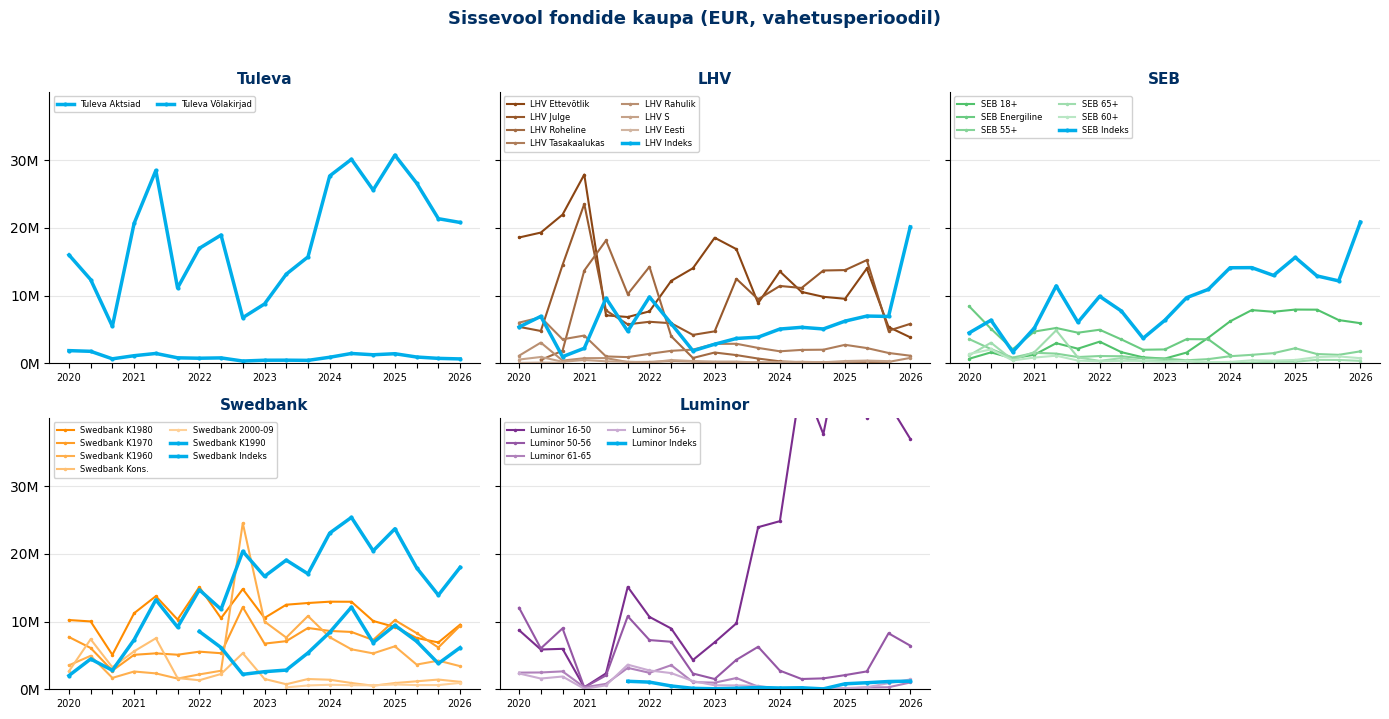

In [5]:
plot_fund_grid(df, 'inflow_amount',
    'Sissevool fondide kaupa (EUR, vahetusperioodil)',
    lambda x, p: f'{x/1e6:.0f}M',
    y_max=40e6, y_ticks=[0, 10e6, 20e6, 30e6])

## Väljavool fondide kaupa

Mitu inimest lahkus igast fondist igal vahetusperioodil?

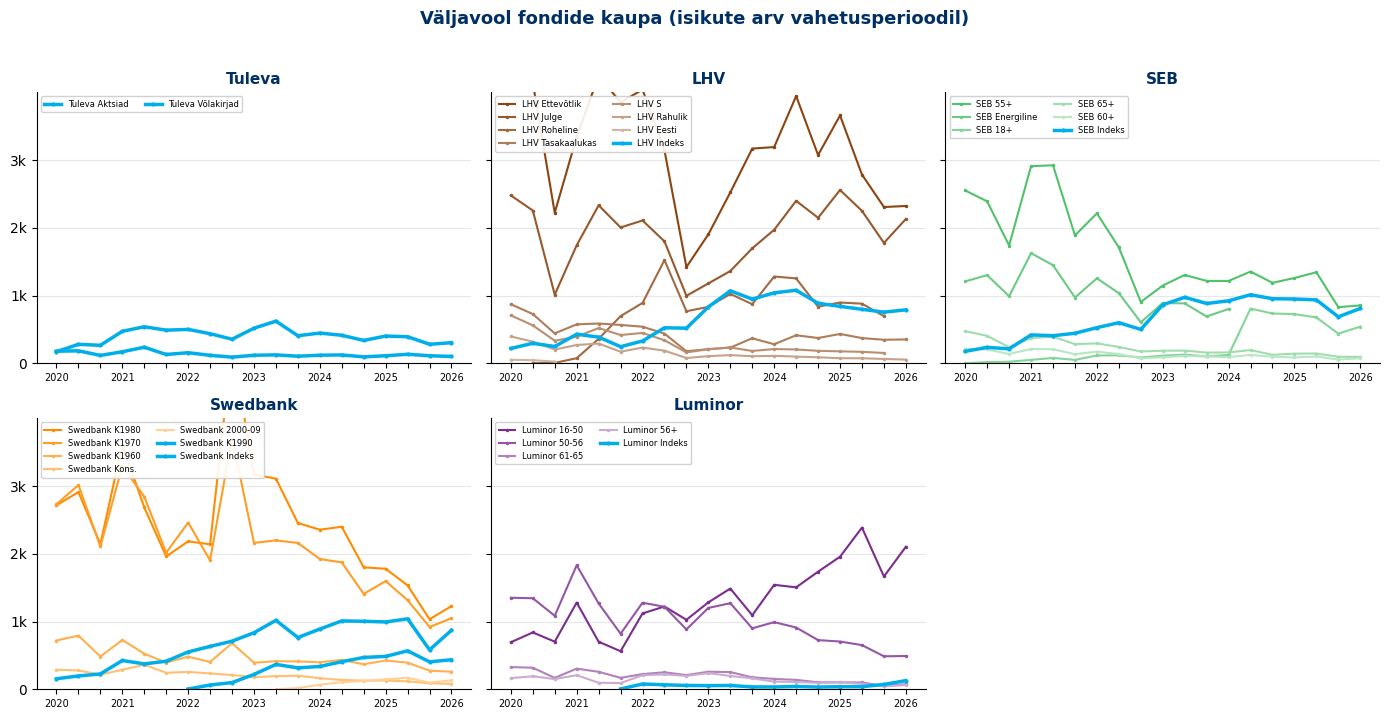

In [6]:
plot_fund_grid(df, 'outflow_count',
    'Väljavool fondide kaupa (isikute arv vahetusperioodil)',
    lambda x, p: f'{x/1000:.0f}k' if x >= 1000 else f'{x:.0f}',
    y_max=4000, y_ticks=[0, 1000, 2000, 3000])

## Väljavool eurodes fondide kaupa

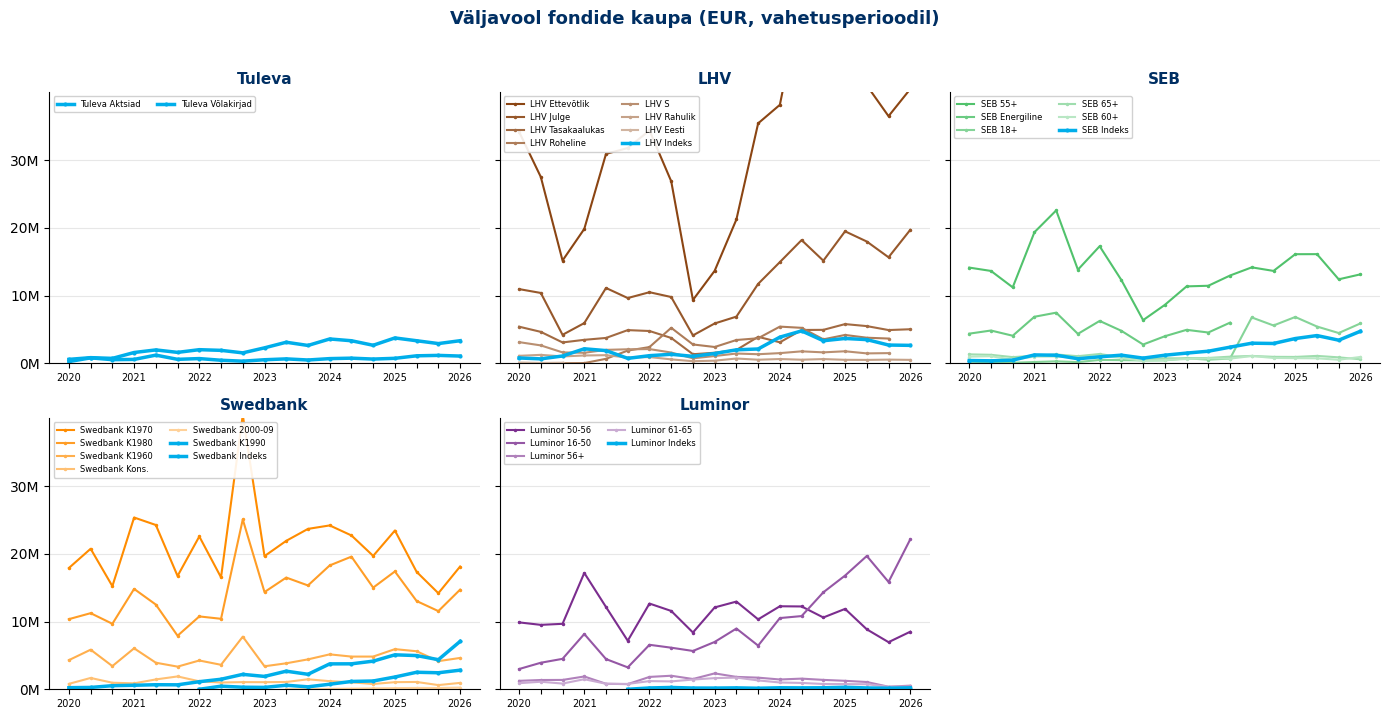

In [7]:
plot_fund_grid(df, 'outflow_amount',
    'Väljavool fondide kaupa (EUR, vahetusperioodil)',
    lambda x, p: f'{x/1e6:.0f}M',
    y_max=40e6, y_ticks=[0, 10e6, 20e6, 30e6])

## Tuleva vs indeksfondid vs ülejäänud

In [8]:
def assign_group(row):
    if row['manager'] == 'Tuleva':
        return 'Tuleva'
    if row['category'] == 'index':
        return 'Muud indeksfondid'
    return f"{row['manager']} (muu)"

df['group'] = df.apply(assign_group, axis=1)

GROUP_ORDER = ['Tuleva', 'Muud indeksfondid', 'LHV (muu)', 'SEB (muu)', 'Swedbank (muu)', 'Luminor (muu)']
GROUP_COLORS = {
    'Tuleva': TULEVA_BLUE,
    'Muud indeksfondid': TULEVA_MID_BLUE,
    'LHV (muu)': '#8B4513',
    'SEB (muu)': '#51c26c',
    'Swedbank (muu)': '#FF8C00',
    'Luminor (muu)': '#7B2D8E',
}

gdf = df.groupby(['period_label', 'period_date', 'group']).agg(
    inflow_count=('inflow_count', 'sum'),
    outflow_count=('outflow_count', 'sum'),
    inflow_amount=('inflow_amount', 'sum'),
    outflow_amount=('outflow_amount', 'sum'),
).reset_index()

print("Groups:", gdf['group'].unique().tolist())

Groups: ['LHV (muu)', 'Luminor (muu)', 'Muud indeksfondid', 'SEB (muu)', 'Swedbank (muu)', 'Tuleva']


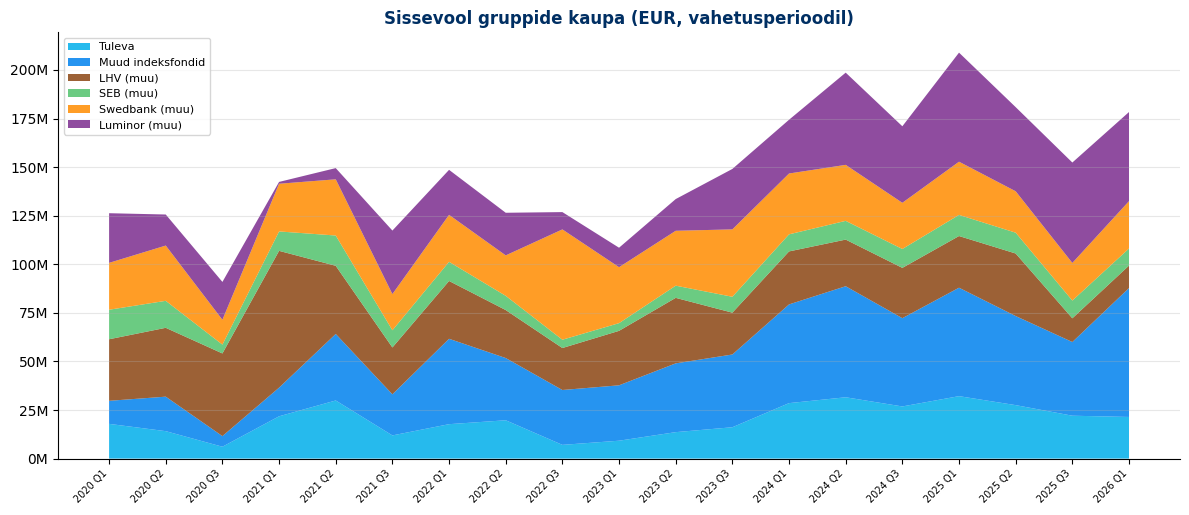

In [9]:
# Inflows by group — stacked area (EUR)
pivot_in = gdf.pivot_table(index='period_date', columns='group', values='inflow_amount', fill_value=0)
pivot_in = pivot_in.reindex(columns=GROUP_ORDER).sort_index()

fig, ax = plt.subplots(figsize=(12, 5.25))
x = range(len(pivot_in))
ax.stackplot(x, [pivot_in[g] / 1e6 for g in GROUP_ORDER],
             labels=GROUP_ORDER, colors=[GROUP_COLORS[g] for g in GROUP_ORDER], alpha=0.85)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:.0f}M'))
ax.set_xticks(range(len(PERIOD_LABELS)))
ax.set_xticklabels(PERIOD_LABELS, rotation=45, ha='right', fontsize=7)
ax.set_title('Sissevool gruppide kaupa (EUR, vahetusperioodil)', fontsize=12, fontweight='bold', color=TULEVA_NAVY)
ax.legend(loc='upper left', fontsize=8)
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
plt.show()

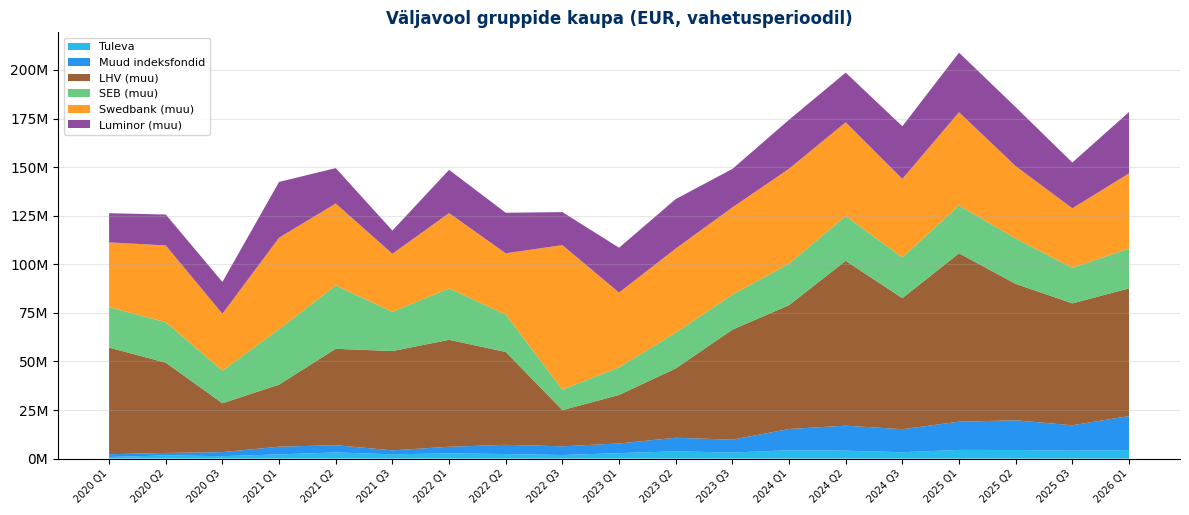

In [10]:
# Outflows by group — stacked area (EUR)
pivot_out = gdf.pivot_table(index='period_date', columns='group', values='outflow_amount', fill_value=0)
pivot_out = pivot_out.reindex(columns=GROUP_ORDER).sort_index()

fig, ax = plt.subplots(figsize=(12, 5.25))
x = range(len(pivot_out))
ax.stackplot(x, [pivot_out[g] / 1e6 for g in GROUP_ORDER],
             labels=GROUP_ORDER, colors=[GROUP_COLORS[g] for g in GROUP_ORDER], alpha=0.85)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:.0f}M'))
ax.set_xticks(range(len(PERIOD_LABELS)))
ax.set_xticklabels(PERIOD_LABELS, rotation=45, ha='right', fontsize=7)
ax.set_title('Väljavool gruppide kaupa (EUR, vahetusperioodil)', fontsize=12, fontweight='bold', color=TULEVA_NAVY)
ax.legend(loc='upper left', fontsize=8)
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
plt.show()

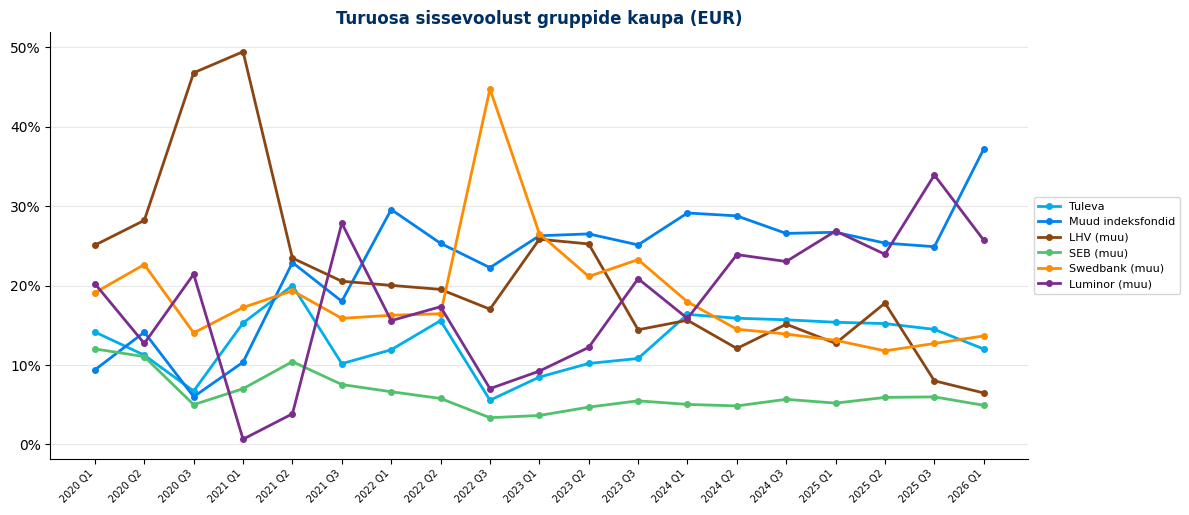

In [11]:
# Market share of inflows by group (%)
share_in = pivot_in.div(pivot_in.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 5.25))
x = range(len(share_in))
for group in GROUP_ORDER:
    ax.plot(x, share_in[group], label=group, color=GROUP_COLORS[group], linewidth=2, marker='o', markersize=4)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:.0f}%'))
ax.set_xticks(range(len(PERIOD_LABELS)))
ax.set_xticklabels(PERIOD_LABELS, rotation=45, ha='right', fontsize=7)
ax.set_title('Turuosa sissevoolust gruppide kaupa (EUR)', fontsize=12, fontweight='bold', color=TULEVA_NAVY)
ax.legend(loc='center left', fontsize=8, bbox_to_anchor=(1, 0.5))
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
plt.show()

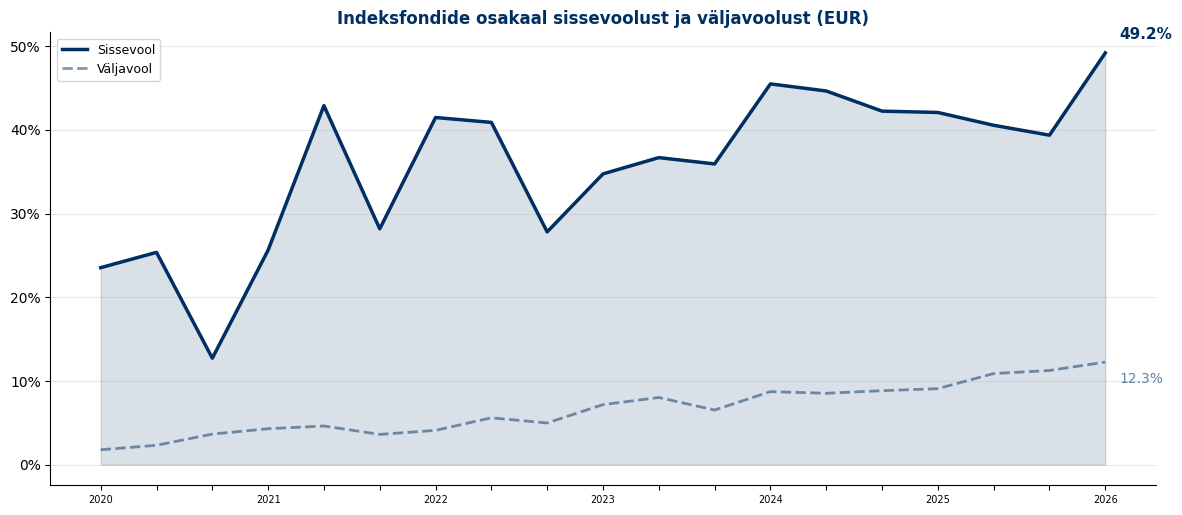

In [12]:
# Combined index fund share of inflows and outflows over time
share_out = pivot_out.div(pivot_out.sum(axis=1), axis=0) * 100
index_share_in = share_in[['Tuleva', 'Muud indeksfondid']].sum(axis=1)
index_share_out = share_out[['Tuleva', 'Muud indeksfondid']].sum(axis=1)

fig, ax = plt.subplots(figsize=(12, 5.25))
x = range(len(index_share_in))
ax.plot(x, index_share_in, color=TULEVA_NAVY, linewidth=2.5, label='Sissevool')
ax.fill_between(x, index_share_in, alpha=0.15, color=TULEVA_NAVY)
ax.plot(x, index_share_out, color=TULEVA_NAVY, linewidth=2, linestyle='--', alpha=0.5, label='Väljavool')

ax.annotate(f"{index_share_in.iloc[-1]:.1f}%", xy=(len(index_share_in)-1, index_share_in.iloc[-1]),
            fontsize=11, fontweight='bold', color=TULEVA_NAVY,
            xytext=(10, 10), textcoords='offset points')
ax.annotate(f"{index_share_out.iloc[-1]:.1f}%", xy=(len(index_share_out)-1, index_share_out.iloc[-1]),
            fontsize=10, color=TULEVA_NAVY, alpha=0.6,
            xytext=(10, -15), textcoords='offset points')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:.0f}%'))
ax.set_xticks(range(len(PERIOD_LABELS)))
ax.set_xticklabels(PERIOD_XLABELS, fontsize=7)
ax.set_title('Indeksfondide osakaal sissevoolust ja väljavoolust (EUR)', fontsize=12, fontweight='bold', color=TULEVA_NAVY)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
plt.show()

## Vahetused fondihalduri kaupa

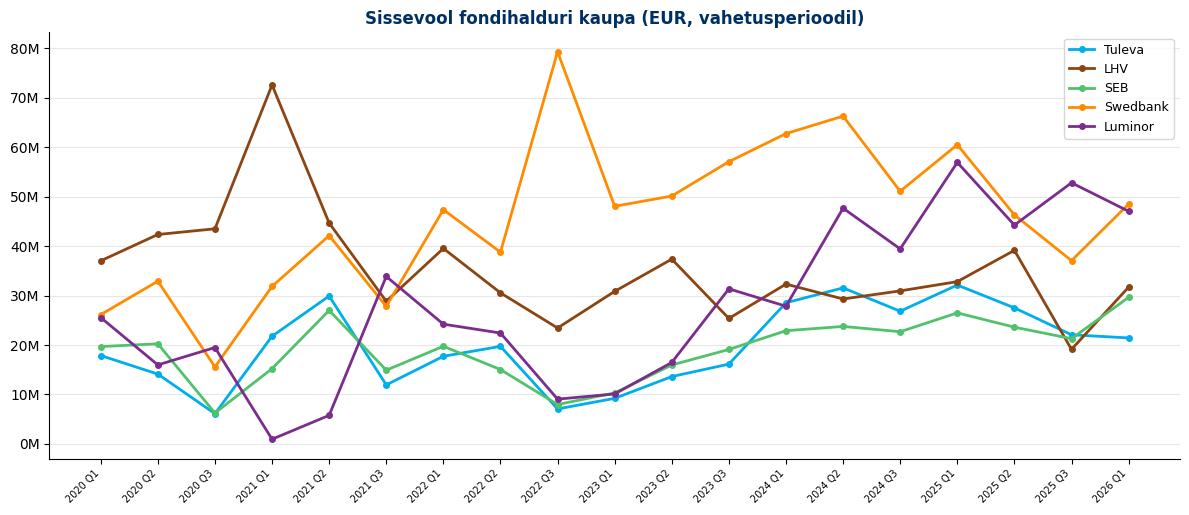

In [13]:
mdf = df.groupby(['period_label', 'period_date', 'manager']).agg(
    inflow_count=('inflow_count', 'sum'),
    outflow_count=('outflow_count', 'sum'),
    inflow_amount=('inflow_amount', 'sum'),
    outflow_amount=('outflow_amount', 'sum'),
).reset_index().sort_values('period_date')

# Inflows by manager (EUR)
fig, ax = plt.subplots(figsize=(12, 5.25))
for manager in MANAGER_ORDER:
    d = mdf[mdf['manager'] == manager]
    x = [PERIOD_LABELS.index(l) for l in d['period_label']]
    ax.plot(x, d['inflow_amount'] / 1e6, label=manager, color=COMPETITOR_COLORS[manager], linewidth=2, marker='o', markersize=4)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:.0f}M'))
ax.set_xticks(range(len(PERIOD_LABELS)))
ax.set_xticklabels(PERIOD_LABELS, rotation=45, ha='right', fontsize=7)
ax.set_title('Sissevool fondihalduri kaupa (EUR, vahetusperioodil)', fontsize=12, fontweight='bold', color=TULEVA_NAVY)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
plt.show()

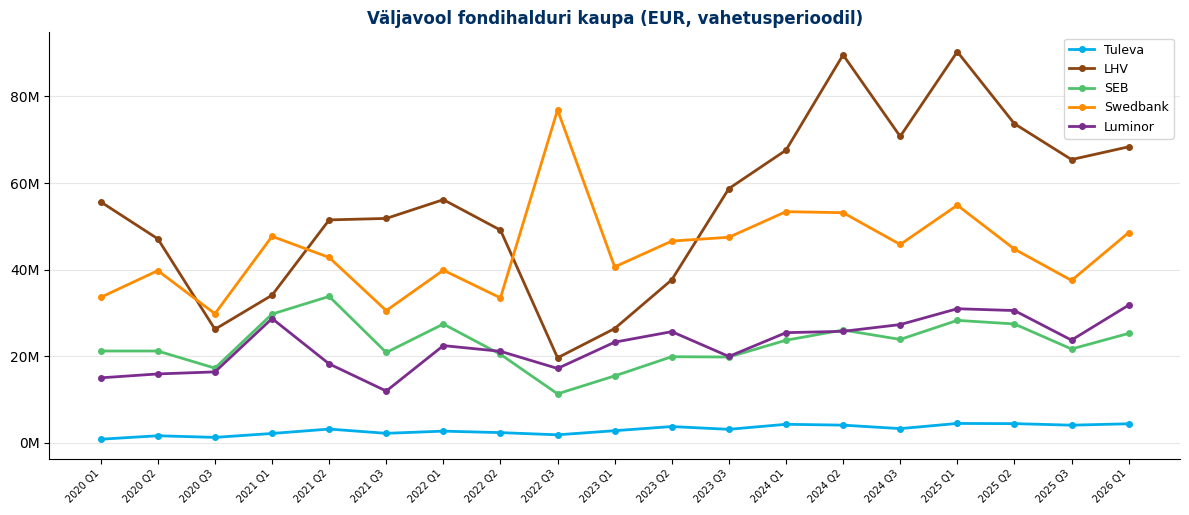

In [14]:
# Outflows by manager (EUR)
fig, ax = plt.subplots(figsize=(12, 5.25))
for manager in MANAGER_ORDER:
    d = mdf[mdf['manager'] == manager]
    x = [PERIOD_LABELS.index(l) for l in d['period_label']]
    ax.plot(x, d['outflow_amount'] / 1e6, label=manager, color=COMPETITOR_COLORS[manager], linewidth=2, marker='o', markersize=4)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:.0f}M'))
ax.set_xticks(range(len(PERIOD_LABELS)))
ax.set_xticklabels(PERIOD_LABELS, rotation=45, ha='right', fontsize=7)
ax.set_title('Väljavool fondihalduri kaupa (EUR, vahetusperioodil)', fontsize=12, fontweight='bold', color=TULEVA_NAVY)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
plt.show()

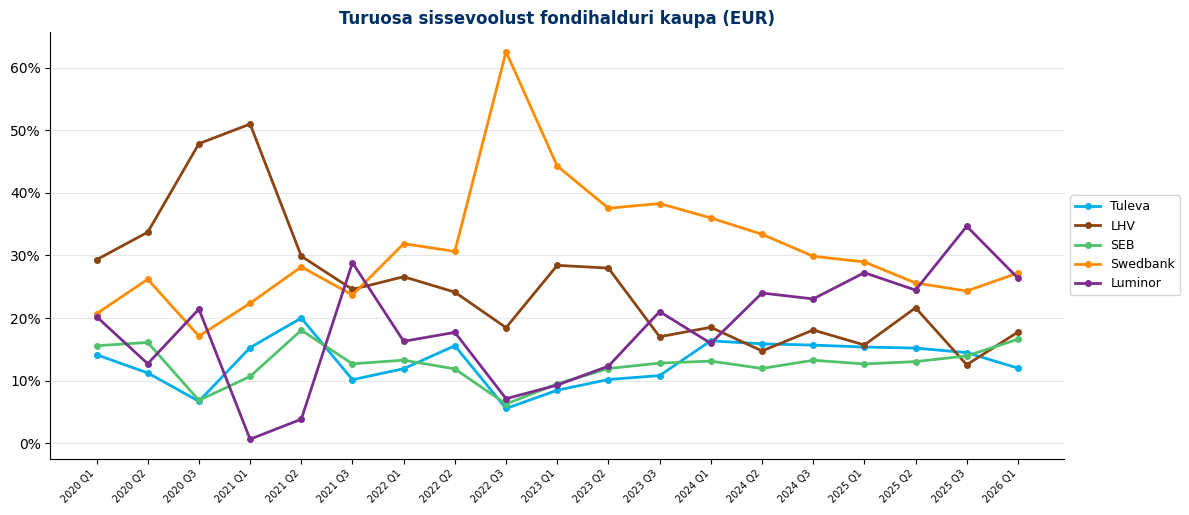

In [15]:
# Market share of inflows by manager (%)
mgr_pivot_in = mdf.pivot_table(index='period_date', columns='manager', values='inflow_amount', fill_value=0).sort_index()
mgr_share_in = mgr_pivot_in.div(mgr_pivot_in.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 5.25))
x = range(len(mgr_share_in))
for manager in MANAGER_ORDER:
    ax.plot(x, mgr_share_in[manager], label=manager, color=COMPETITOR_COLORS[manager], linewidth=2, marker='o', markersize=4)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:.0f}%'))
ax.set_xticks(range(len(PERIOD_LABELS)))
ax.set_xticklabels(PERIOD_LABELS, rotation=45, ha='right', fontsize=7)
ax.set_title('Turuosa sissevoolust fondihalduri kaupa (EUR)', fontsize=12, fontweight='bold', color=TULEVA_NAVY)
ax.legend(loc='center left', fontsize=9, bbox_to_anchor=(1, 0.5))
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
plt.show()

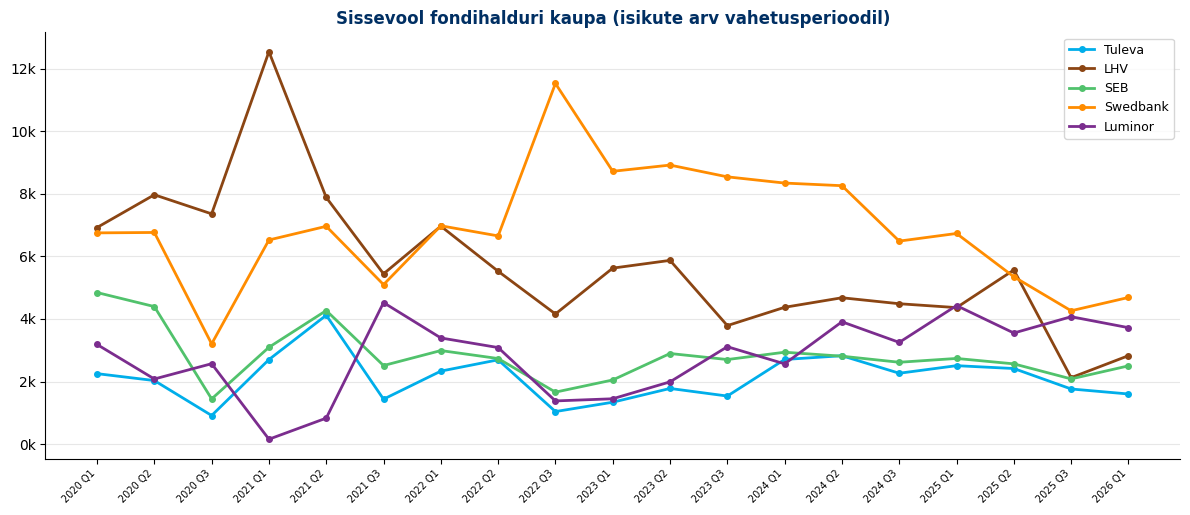

In [16]:
# Inflows by manager (people count)
fig, ax = plt.subplots(figsize=(12, 5.25))
for manager in MANAGER_ORDER:
    d = mdf[mdf['manager'] == manager]
    x = [PERIOD_LABELS.index(l) for l in d['period_label']]
    ax.plot(x, d['inflow_count'] / 1000, label=manager, color=COMPETITOR_COLORS[manager], linewidth=2, marker='o', markersize=4)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:.0f}k'))
ax.set_xticks(range(len(PERIOD_LABELS)))
ax.set_xticklabels(PERIOD_LABELS, rotation=45, ha='right', fontsize=7)
ax.set_title('Sissevool fondihalduri kaupa (isikute arv vahetusperioodil)', fontsize=12, fontweight='bold', color=TULEVA_NAVY)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
plt.show()

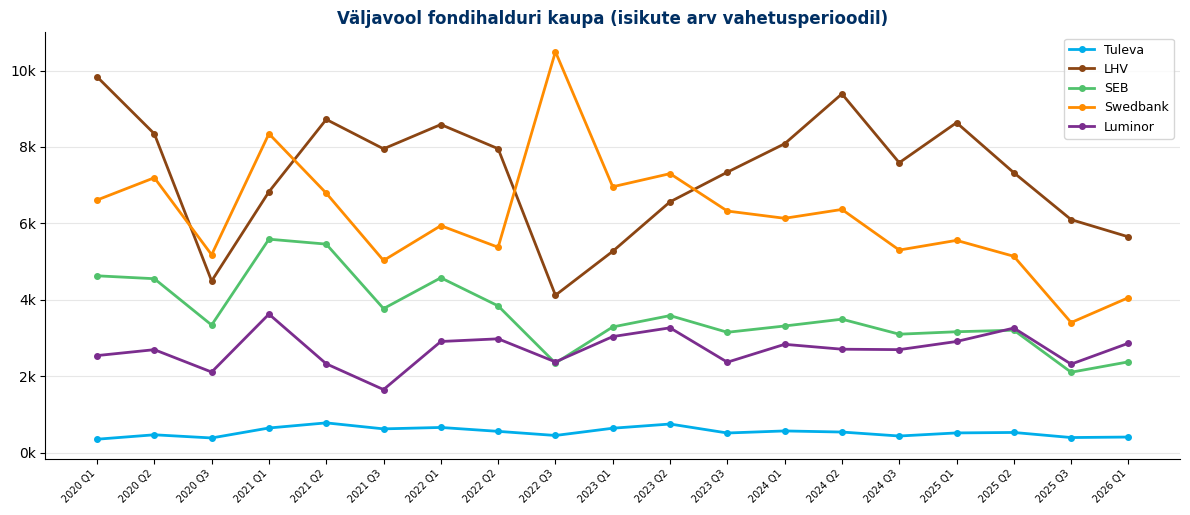

In [17]:
# Outflows by manager (people count)
fig, ax = plt.subplots(figsize=(12, 5.25))
for manager in MANAGER_ORDER:
    d = mdf[mdf['manager'] == manager]
    x = [PERIOD_LABELS.index(l) for l in d['period_label']]
    ax.plot(x, d['outflow_count'] / 1000, label=manager, color=COMPETITOR_COLORS[manager], linewidth=2, marker='o', markersize=4)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:.0f}k'))
ax.set_xticks(range(len(PERIOD_LABELS)))
ax.set_xticklabels(PERIOD_LABELS, rotation=45, ha='right', fontsize=7)
ax.set_title('Väljavool fondihalduri kaupa (isikute arv vahetusperioodil)', fontsize=12, fontweight='bold', color=TULEVA_NAVY)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
plt.show()